# Part 5: Monitoring and Drift Detection

This notebook simulates six months of production data, detects drift with PSI and KS tests, scores the deployed HW2 model, and creates the required three-panel monitoring dashboard.

In [8]:
from pathlib import Path
import os

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from common import FEATURES, NUMERIC_FEATURES, TARGET, find_data_path, get_feature_target

%matplotlib inline

pd.set_option('display.max_columns', 100)
rng = np.random.default_rng(42)
DATA_PATH = find_data_path()
print(f"Detected dataset: {DATA_PATH.name}")

Detected dataset: olist_cleaned_integrated_dataset (3).csv


In [9]:
X, y, agg = get_feature_target(DATA_PATH)
reference = X.copy()
reference[TARGET] = y.values
print(reference.shape)
print('Positive rate:', reference[TARGET].mean())

model_path = Path('model/model.pkl')
if not model_path.exists():
    raise FileNotFoundError('model/model.pkl not found. Run python train_and_serialize.py first.')
model = joblib.load(model_path)

(99441, 22)
Positive rate: 0.7613258112850836


## 5A. Production Data Simulation

Months 1-3 are stable with small numeric noise. Months 4-6 introduce increasing delivery, freight, product-mix, and label drift.

In [10]:
def add_numeric_noise(frame, pct=0.05):
    out = frame.copy()
    for col in NUMERIC_FEATURES:
        noise = rng.uniform(1 - pct, 1 + pct, size=len(out))
        if col == 'delivery_vs_estimated':
            out[col] = out[col] + rng.normal(0, max(out[col].std() * 0.02, 0.01), len(out))
        elif col in {'seller_state_match', 'is_repeat_customer', 'is_weekend_purchase', 'order_hour', 'order_dayofweek'}:
            continue
        else:
            out[col] = out[col] * noise
    return out

def increase_electronics_share(frame, increase_share):
    out = frame.copy()
    target_n = int(len(out) * increase_share)
    candidates = out.index[out['product_category'] != 'electronics'].to_numpy()
    if len(candidates) > 0 and target_n > 0:
        chosen = rng.choice(candidates, size=min(target_n, len(candidates)), replace=False)
        out.loc[chosen, 'product_category'] = 'electronics'
    return out

def flip_positive_labels(labels, pct=0.05):
    labels = labels.copy()
    positives = labels.index[labels == 1].to_numpy()
    flip_n = int(len(positives) * pct)
    if flip_n > 0:
        chosen = rng.choice(positives, size=flip_n, replace=False)
        labels.loc[chosen] = 0
    return labels

months = []
for month in range(1, 7):
    sample = reference.sample(n=3000, replace=False, random_state=42 + month).reset_index(drop=True)
    labels = sample[TARGET].copy()
    prod = sample[FEATURES].copy()
    prod = add_numeric_noise(prod, pct=0.05)

    if month >= 4:
        delivery_shift = {4: 2, 5: 4, 6: 6}[month]
        freight_multiplier = {4: 1.15, 5: 1.30, 6: 1.50}[month]
        electronics_increase = {4: 0.10, 5: 0.15, 6: 0.20}[month]

        prod['delivery_days'] = prod['delivery_days'] + delivery_shift
        prod['delivery_vs_estimated'] = prod['delivery_vs_estimated'] + delivery_shift
        prod['total_freight'] = prod['total_freight'] * freight_multiplier
        prod['total_order_value'] = prod['total_price'] + prod['total_freight']
        prod['log_total_order_value'] = np.log1p(prod['total_order_value'].clip(lower=0))
        prod['freight_share'] = prod['total_freight'] / prod['total_order_value'].replace(0, np.nan)
        prod['payment_value_total'] = prod['total_order_value']
        prod = increase_electronics_share(prod, electronics_increase)
        labels = flip_positive_labels(labels, pct=0.05)

    prod[TARGET] = labels.values
    prod['month'] = month
    months.append(prod)

production = pd.concat(months, ignore_index=True)
print(production.shape)
display(production.groupby('month')[TARGET].agg(['count', 'mean']))

(18000, 23)


,count,mean
month,,
1,3000,0.771333
2,3000,0.764667
3,3000,0.757000
4,3000,0.732000
5,3000,0.715000
6,3000,0.721000


## 5B. Statistical Drift Detection

PSI uses 10 equal-width bins. KS tests compare each simulated month to the training reference distribution.

In [11]:
drift_features = ['delivery_days', 'total_freight', 'total_price']

def calculate_psi(expected, actual, bins=10, epsilon=0.0001):
    expected = pd.Series(expected).dropna().astype(float)
    actual = pd.Series(actual).dropna().astype(float)
    edges = np.linspace(expected.min(), expected.max(), bins + 1)
    edges[0] = -np.inf
    edges[-1] = np.inf
    expected_counts = pd.cut(expected, bins=edges).value_counts(sort=False)
    actual_counts = pd.cut(actual, bins=edges).value_counts(sort=False)
    expected_pct = (expected_counts / expected_counts.sum()).replace(0, epsilon)
    actual_pct = (actual_counts / actual_counts.sum()).replace(0, epsilon)
    return float(((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)).sum())

psi_rows = []
ks_rows = []
for feature in drift_features:
    row = {'feature': feature}
    for month in range(1, 7):
        actual = production.loc[production['month'] == month, feature]
        psi = calculate_psi(reference[feature], actual, bins=10)
        row[f'Month {month}'] = psi
        ks_stat, p_value = ks_2samp(reference[feature].dropna(), actual.dropna())
        ks_rows.append({
            'feature': feature,
            'month': month,
            'ks_statistic': ks_stat,
            'p_value': p_value,
            'significant_p_lt_0_05': p_value < 0.05,
        })
    psi_rows.append(row)

psi_table = pd.DataFrame(psi_rows).set_index('feature')
ks_table = pd.DataFrame(ks_rows)

def severity(value):
    if value < 0.1:
        return 'stable'
    if value < 0.2:
        return 'moderate'
    return 'significant'

psi_severity = psi_table.map(severity)
display(psi_table)
display(psi_severity)
display(ks_table)

,Month 1,Month 2,Month 3,Month 4,Month 5,Month 6
feature,,,,,,
delivery_days,0.001678,0.001460,0.000866,0.012986,0.045631,0.137601
total_freight,0.000615,0.002075,0.000953,0.001649,0.006033,0.004724
total_price,0.000548,0.002267,0.003620,0.000480,0.001228,0.002711


,Month 1,Month 2,Month 3,Month 4,Month 5,Month 6
feature,,,,,,
delivery_days,stable,stable,stable,stable,stable,moderate
total_freight,stable,stable,stable,stable,stable,stable
total_price,stable,stable,stable,stable,stable,stable


,feature,month,ks_statistic,p_value,significant_p_lt_0_05
0,delivery_days,1,0.042922,5.692775e-05,True
1,delivery_days,2,0.049514,1.844713e-06,True
2,delivery_days,3,0.047765,4.972341e-06,True
3,delivery_days,4,0.176247,3.154571e-77,True
4,delivery_days,5,0.307436,6.971254e-237,True
5,delivery_days,6,0.424120,0.000000e+00,True
6,total_freight,1,0.021464,1.346993e-01,False
7,total_freight,2,0.021749,1.253660e-01,False
8,total_freight,3,0.036416,8.622217e-04,True
9,total_freight,4,0.178534,1.129352e-81,True


## 5C. Performance Monitoring

In [12]:
scored = production.copy()
scored['probability'] = model.predict_proba(scored[FEATURES])[:, 1]
scored['prediction'] = (scored['probability'] >= 0.5).astype(int)

metric_rows = []
for month, group in scored.groupby('month'):
    metric_rows.append({
        'month': month,
        'accuracy': accuracy_score(group[TARGET], group['prediction']),
        'f1': f1_score(group[TARGET], group['prediction'], zero_division=0),
        'auc': roc_auc_score(group[TARGET], group['probability']),
    })
metrics = pd.DataFrame(metric_rows)
display(metrics)

f1_m1 = metrics.loc[metrics['month'] == 1, 'f1'].iloc[0]
f1_m6 = metrics.loc[metrics['month'] == 6, 'f1'].iloc[0]
auc_m1 = metrics.loc[metrics['month'] == 1, 'auc'].iloc[0]
auc_m6 = metrics.loc[metrics['month'] == 6, 'auc'].iloc[0]

print(f'F1 dropped from {f1_m1:.3f} to {f1_m6:.3f}: absolute drop {f1_m1 - f1_m6:.3f}, percent drop {(f1_m1 - f1_m6) / f1_m1 * 100:.1f}%')
print(f'AUC dropped from {auc_m1:.3f} to {auc_m6:.3f}: absolute drop {auc_m1 - auc_m6:.3f}, percent drop {(auc_m1 - auc_m6) / auc_m1 * 100:.1f}%')

,month,accuracy,f1,auc
0,1,0.820667,0.894840,0.841578
1,2,0.827000,0.897573,0.860397
2,3,0.811000,0.888188,0.852416
3,4,0.788333,0.871014,0.767700
4,5,0.760667,0.850229,0.742294
5,6,0.751000,0.842505,0.705216


F1 dropped from 0.895 to 0.843: absolute drop 0.052, percent drop 5.8%
AUC dropped from 0.842 to 0.705: absolute drop 0.136, percent drop 16.2%


## 5D. Three-Panel Monitoring Dashboard

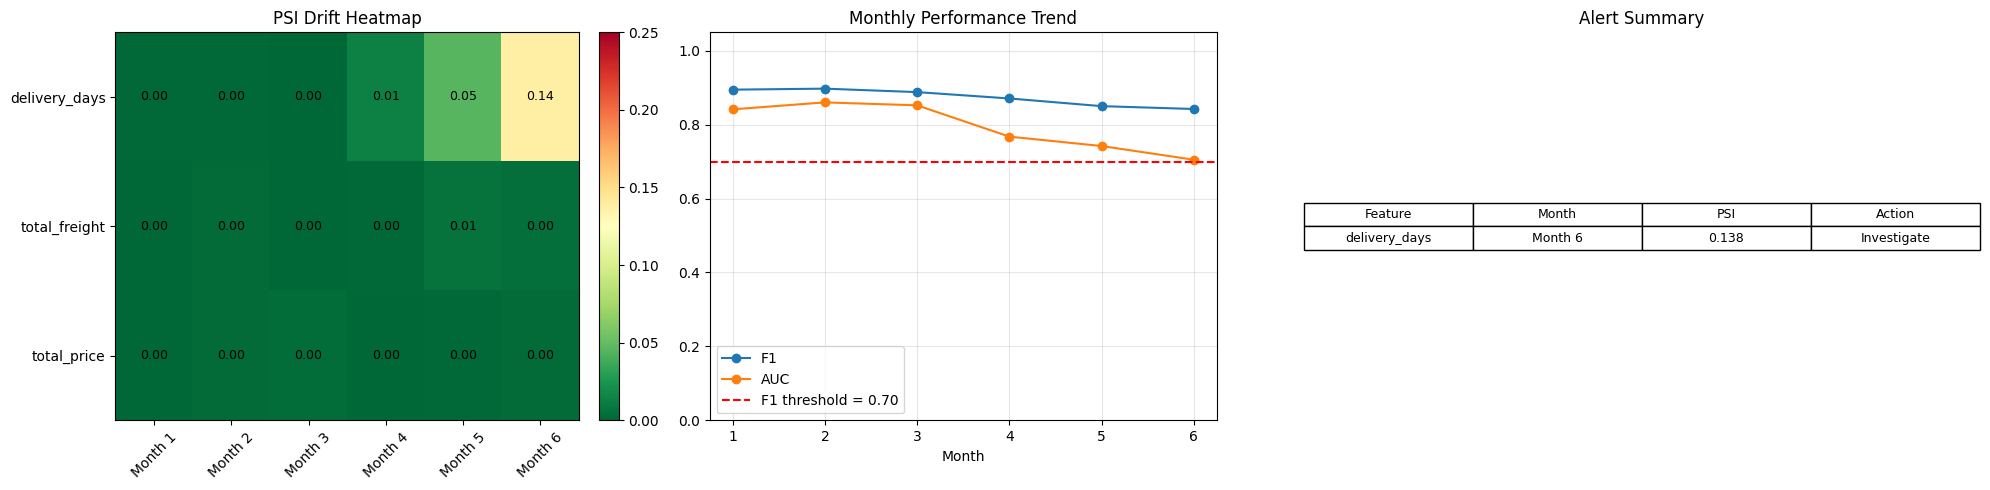

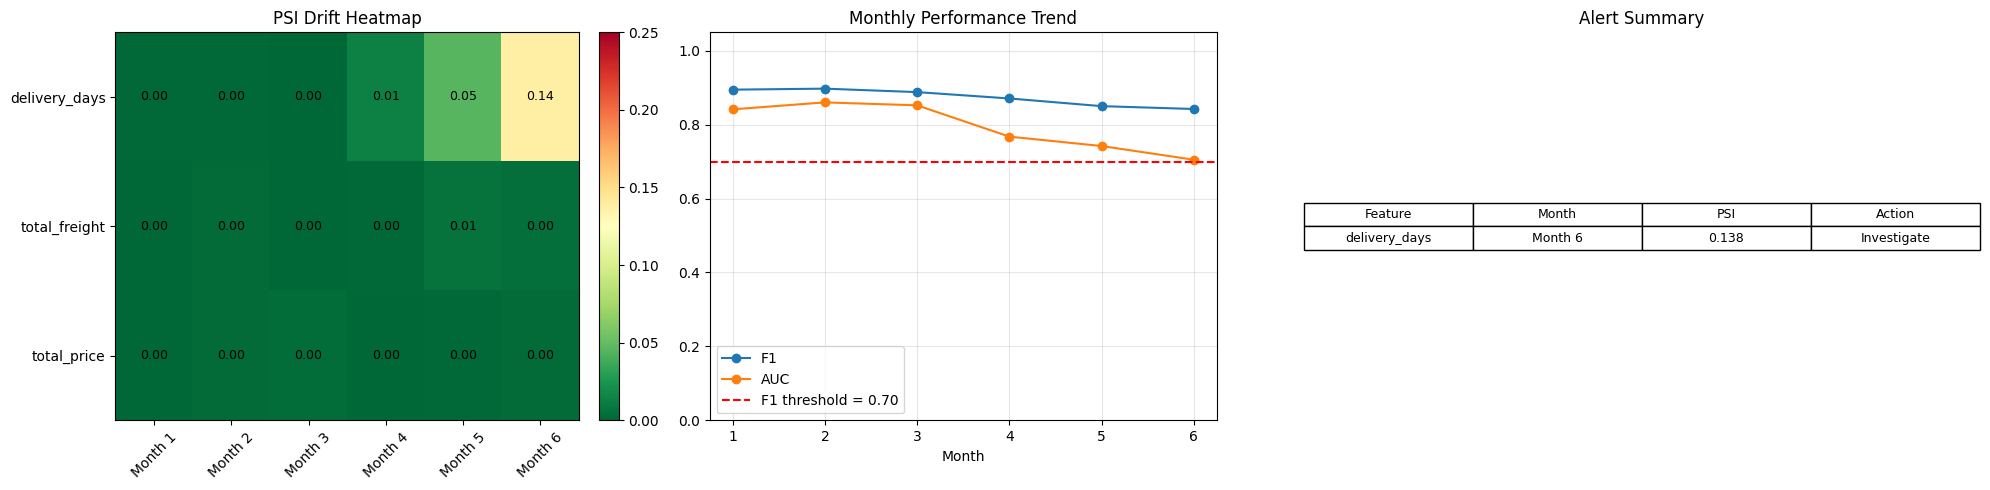

In [13]:
alerts = []
for feature in psi_table.index:
    for month_label, value in psi_table.loc[feature].items():
        sev = severity(value)
        if sev != 'stable':
            alerts.append({
                'Feature': feature,
                'Month': month_label,
                'PSI': round(value, 3),
                'Action': 'Retrain candidate' if sev == 'significant' else 'Investigate',
            })
alert_table = pd.DataFrame(alerts)
if alert_table.empty:
    alert_table = pd.DataFrame([{'Feature': 'None', 'Month': '-', 'PSI': 0.0, 'Action': 'Continue monitoring'}])

fig, axes = plt.subplots(1, 3, figsize=(20, 5), gridspec_kw={'width_ratios': [1.2, 1.2, 1.6]})

heatmap_values = psi_table.values
im = axes[0].imshow(heatmap_values, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=max(0.25, heatmap_values.max()))
axes[0].set_xticks(range(6), psi_table.columns, rotation=45)
axes[0].set_yticks(range(len(psi_table.index)), psi_table.index)
axes[0].set_title('PSI Drift Heatmap')
for i in range(heatmap_values.shape[0]):
    for j in range(heatmap_values.shape[1]):
        axes[0].text(j, i, f'{heatmap_values[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].plot(metrics['month'], metrics['f1'], marker='o', label='F1')
axes[1].plot(metrics['month'], metrics['auc'], marker='o', label='AUC')
axes[1].axhline(0.70, color='red', linestyle='--', label='F1 threshold = 0.70')
axes[1].set_xticks(metrics['month'])
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Monthly Performance Trend')
axes[1].set_xlabel('Month')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].axis('off')
show_alerts = alert_table.head(8)
table = axes[2].table(
    cellText=show_alerts.values,
    colLabels=show_alerts.columns,
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)
axes[2].set_title('Alert Summary')

plt.tight_layout()
plt.show()

## 5E. Retraining Recommendation

The model should be retrained when drift becomes sustained rather than isolated. I would trigger retraining when any monitored high-importance numeric feature reaches PSI >= 0.2 for two consecutive months, or when F1 drops by at least 10% from the stable baseline while AUC also declines. In this simulation, months 4-6 create systematic pressure on delivery time, freight cost, and product mix, and the label flips represent concept drift in customer expectations. That combination is more serious than ordinary month-to-month variation.

The retraining dataset should include the original HW2 training data plus the newest production months after labels are mature, with special attention to the drifted delivery and freight regimes. I would also preserve month or recency indicators for offline analysis, validate whether the feature distributions remain business-valid, and rerun calibration checks before promotion. If the foundation-model review-text workflow is available, its outputs could enrich post-delivery monitoring, but the production model should still be trained on proactive pre-review signals so the business can intervene before dissatisfaction is written into a review.